In [106]:
"""COE 311K Final

Alan Ji ayj333

Zachary Matthews zrm494

"""

pass

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Section 1: Review of Pt 2

In [108]:
"""
Recap: 

We chose to model the stiff system of cooling with forced convection. 

Stiffness Ratio is 10^5, which is very large, meaning the problem is stiff.

"""

pass

In [109]:
y0 = 500 # (T)
t0 = 0
t_final = 20


def dR_dT(h):
    return 1 + 1000*h


def f(t, T):
    return (-1000 * T + 1000*(300 + 50*np.sin(0.01*t)))


def residual(T_new, T_old, t_new, h):
    return T_new - T_old - h * f(t_new, T_new) 


# Newton-Raphson solver
def newton_solver(T_guess, T_old, t_new, h, tol=1e-8, max_iter=10):
    T = T_guess
    for _ in range(max_iter):
        R = residual(T, T_old, t_new, h)
        dR = dR_dT(h)
        T_new = T - R / dR
        
        if abs(T_new - T) < tol:
            return T_new
        
        T = T_new
    return T  # fallback

# Backward Euler
def backward_euler(T0, t0, tf, h):
    t_vals = np.arange(t0, tf + h, h)
    T_vals = np.zeros(len(t_vals))
    
    T_vals[0] = T0
    
    for i in range(len(t_vals) - 1):
        t_new = t_vals[i+1]
        
        # initial guess = previous value
        T_guess = T_vals[i]
        
        T_vals[i+1] = newton_solver(T_guess, T_vals[i], t_new, h)
    
    return t_vals, T_vals



# Section 2: NR Damping Implementation

In [110]:
"""
The idea is to choose α (dampening factor) to ensure the residual decreases at each iteration.

When α = 1, it means that NR method is working.
When α < 1, it means that smaller steps are needed to ensure convergence.
"""

pass

In [111]:
def basic_newton_raphson(y_n, t_next, h, g_func, g_prime_func, 
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n
    
    for k in range(max_iter):
        g = g_func(t_next, y_guess)
        
        if abs(g) < tol:
            return y_guess, k, True
        
        g_prime = g_prime_func(h)
        delta = -g / g_prime
        
        y_new = y_guess + delta
            
        y_guess = y_new
    
    return y_guess, max_iter, False



def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, 
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    y_guess = y_n
    
    for k in range(max_iter):
        g = g_func(t_next, y_guess)
        
        g_prime = 1 - h*g_prime_func(h)
        delta = -g / g_prime
        
        if abs(delta) < tol:
            return y_guess, k, True
        
        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
        
        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(t_next, y_new))
            
            if g_new < g_current:  # Sufficient decrease
                break
            
            alpha = alpha / 2.0
            
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False
        
        y_guess = y_new
    
    return y_guess, max_iter, False

In [137]:
# Demonstration for dampening in very large h

# Problem where undamped NR fails
h_large = 2.0  # Very large step size

print("Testing undamped NR with h = 2.0:")
try:
    y_damped, iters, success = basic_newton_raphson(y0, t0+h_large, h_large, f, dR_dT, max_iter=100)
    print(f"Converged: {success}, Iterations: {iters}")
except:
    print("Failed to converge!")

print("\nTesting damped NR with h = 2.0:")
y_damped, iters, success = damped_newton_raphson(y0, t0+h_large, h_large, f, dR_dT, max_iter=100)
print(f"Converged: {success}, iterations: {iters}")

Testing undamped NR with h = 2.0:
Converged: False, Iterations: 100

Testing damped NR with h = 2.0:
Converged: True, iterations: 78


# Section 3: Implementation

In [126]:
def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol,
                           h_min=1e-6, h_max=1.0,
                           nr_tol=1e-8, max_nr_iter=20):
    """
    Adaptive Euler's Backward with damped Newton-Raphson
    """

    def newton_step(y_guess, y_prev, t_new, h):
        """Solve: y - y_prev - h*f(t_new, y) = 0"""
        yk = y_guess.copy()
        damping_used = False

        for k in range(max_nr_iter):
            F = yk - y_prev - h * f(t_new, yk)
            stats['function_evals'] += 1

            if np.linalg.norm(F) < nr_tol:
                return yk, k+1, damping_used, True

            # Finite-difference Jacobian
            n = len(yk) if np.ndim(yk) > 0 else 1
            J = np.zeros((n, n)) if n > 1 else np.zeros((1, 1))
            eps = 1e-8

            for i in range(n):
                y_pert = np.array(yk, dtype=float)
                if n == 1:
                    y_pert = np.array([yk])
                y_pert[i] += eps
                F_pert = y_pert - y_prev - h * f(t_new, y_pert)
                stats['function_evals'] += 1
                J[:, i] = (F_pert - F) / eps

            if n == 1:
                delta = -F / J[0, 0]
            else:
                delta = np.linalg.solve(J, -F)

            # Damping (backtracking)
            alpha = 1.0
            while alpha > 1e-4:
                y_trial = yk + alpha * delta
                F_trial = y_trial - y_prev - h * f(t_new, y_trial)
                stats['function_evals'] += 1

                if np.linalg.norm(F_trial) < np.linalg.norm(F):
                    break
                alpha *= 0.5
                damping_used = True

            yk = yk + alpha * delta

        return yk, max_nr_iter, damping_used, False

    # Initialize
    t = [t0]
    y = [np.array(y0, dtype=float)]
    h = h0
    h_history = []
    e_hist = []

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used': 0,
        'function_evals': 0
    }

    # Main loop
    while t[-1] < t_final:
        h = min(h, t_final - t[-1])
        y_prev = y[-1]
        t_new = t[-1] + h

        # --- Full step ---
        y_guess = y_prev.copy()
        y_full, iters_full, damp_full, ok_full = newton_step(y_guess, y_prev, t_new, h)

        # --- Two half steps ---
        h_half = h / 2
        t_mid = t[-1] + h_half

        y_half1, it1, damp1, ok1 = newton_step(y_prev.copy(), y_prev, t_mid, h_half)
        y_half2, it2, damp2, ok2 = newton_step(y_half1.copy(), y_half1, t_new, h_half)

        # Collect stats
        stats['nr_iterations'].append(iters_full + it1 + it2)
        if damp_full or damp1 or damp2:
            stats['damping_used'] += 1

        if not (ok_full and ok1 and ok2):
            # Newton failed → shrink step
            h = max(h * 0.5, h_min)
            stats['rejected_steps'] += 1
            continue

        # Error estimate (difference between full and half)
        err = np.linalg.norm(y_half2 - y_full)

        if err < tol or h <= h_min:
            # Accept step
            t.append(t_new)
            y.append(y_half2)  # higher accuracy
            h_history.append(h)
            e_hist.append(err)
            stats['accepted_steps'] += 1

            # Adapt step size (1st order method → exponent 1/2)
            if err == 0:
                factor = 2.0
            else:
                factor = 0.9 * (tol / err) ** 0.5

            h = min(h_max, max(h_min, factor * h))

        else:
            # Reject step
            h = max(h_min, 0.5 * h)
            stats['rejected_steps'] += 1

    return np.array(t), np.array(y), np.array(h_history), np.array(e_hist), stats


Performance Comparison:
Method               Steps      Func Evals     
------------------------------------------------------------
Fixed (h=0.01)       2002       6006           
Adaptive             1594       32685          


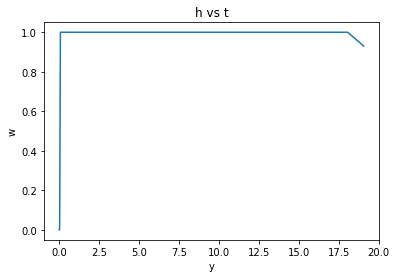

In [132]:
# Fixed step size (baseline)
t_fixed, y_fixed = backward_euler(y0, t0, t_final, h=0.01)

# Adaptive step size (same target accuracy)
t_adapt, y_adapt, h_hist, e_hist, stats = adaptive_implicit_euler(
    f, y0, t0, t_final, h0=0.1, tol=1e-4
)

print("\nPerformance Comparison:")
print(f"{'Method':<20} {'Steps':<10} {'Func Evals':<15}")
print("-" * 60)
print(f"{'Fixed (h=0.01)':<20} {len(t_fixed):<10} {len(t_fixed)*3:<15}")
print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {stats['function_evals']:<15}")


plt.plot(t_adapt[:-1], h_hist)
plt.xlabel('y')
plt.ylabel('w')
plt.title("h vs t")
plt.show()


# Section 4: Performance Analysis

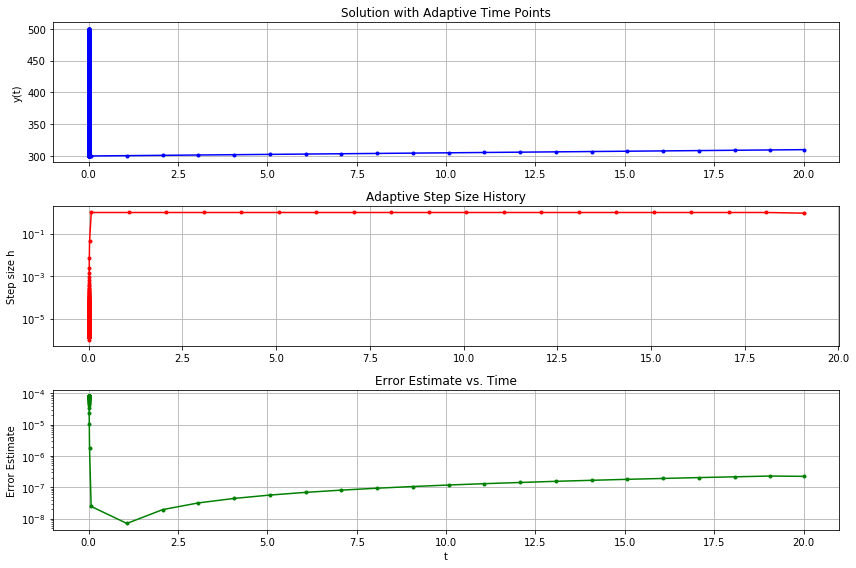

In [133]:
# Visualize how step size adapts
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, 'b-o', markersize=3)
plt.ylabel('y(t)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)

plt.subplot(3, 1, 3)
# Plot error estimate
plt.semilogy(t_adapt[1:], e_hist, 'g-o', markersize=3)
plt.ylabel('Error Estimate')
plt.xlabel('t')
plt.title('Error Estimate vs. Time')
plt.grid(True)

plt.tight_layout()
plt.show()


In [136]:
print(f"{stats['accepted_steps']=}, {stats['rejected_steps']=}")

stats['accepted_steps']=1594, stats['rejected_steps']=17


### Comparison Table

| Feature	| Fixed Step Size| Adaptive Step Size |
|-|-|-|
| Definition |	Uses a constant step size h throughout the computation	| Step size h changes dynamically based on error estimates |
|Accuracy Control|	Accuracy depends entirely on chosen step size|	Automatically adjusts to maintain desired accuracy|
|Efficiency	|Can be inefficient (small h everywhere even when not needed)|	More efficient (larger steps where possible, smaller where needed)|
|Implementation	|Simple to implement|	More complex (requires error estimation and control logic)
|Computational Cost	|Predictable and uniform	|Variable cost depending on problem behavior|
|Stability|	May become unstable if step size is too large|	Better stability due to dynamic adjustment|
|Error Handling|	No built-in error correction|	Built-in local error estimation and correction|
|Use Case|	Suitable for simple or well-behaved problems|	Ideal for stiff or rapidly changing systems|

# Section 5: Robustness Testing


Performance Comparison:
Method               Steps      Func Evals     
------------------------------------------------------------
Fixed (h=0.01)       2002       6006           
Adaptive             1594       32760          


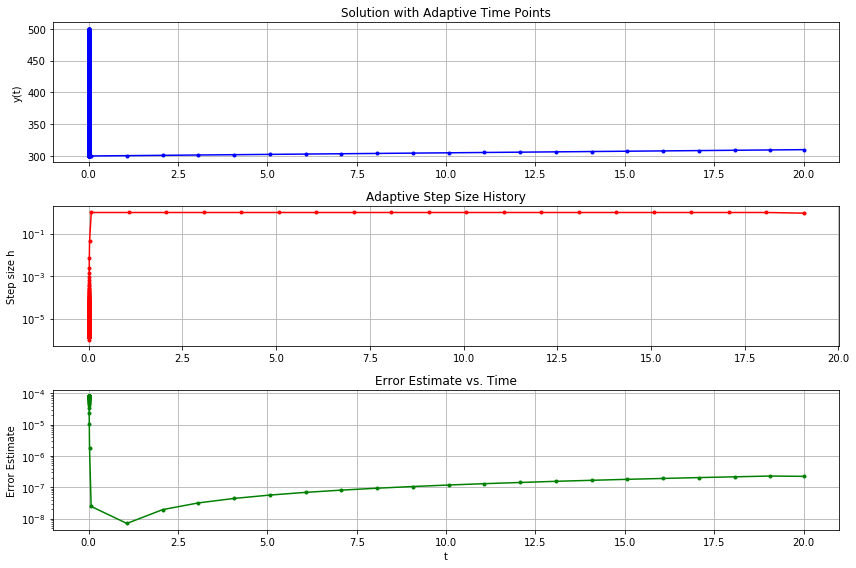

In [139]:
# For Large initial h0

t_adapt, y_adapt, h_hist, e_hist, stats = adaptive_implicit_euler(
    f, y0, t0, t_final, h0=1.0, tol=1e-4
)

print("\nPerformance Comparison:")
print(f"{'Method':<20} {'Steps':<10} {'Func Evals':<15}")
print("-" * 60)
print(f"{'Fixed (h=0.01)':<20} {len(t_fixed):<10} {len(t_fixed)*3:<15}")
print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {stats['function_evals']:<15}")


# Visualize how step size adapts
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, 'b-o', markersize=3)
plt.ylabel('y(t)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)

plt.subplot(3, 1, 3)
# Plot error estimate
plt.semilogy(t_adapt[1:], e_hist, 'g-o', markersize=3)
plt.ylabel('Error Estimate')
plt.xlabel('t')
plt.title('Error Estimate vs. Time')
plt.grid(True)

plt.tight_layout()
plt.show()



Performance Comparison:
Method               Steps      Func Evals     
------------------------------------------------------------
Fixed (h=0.01)       2002       6006           
Adaptive             11033      156273         


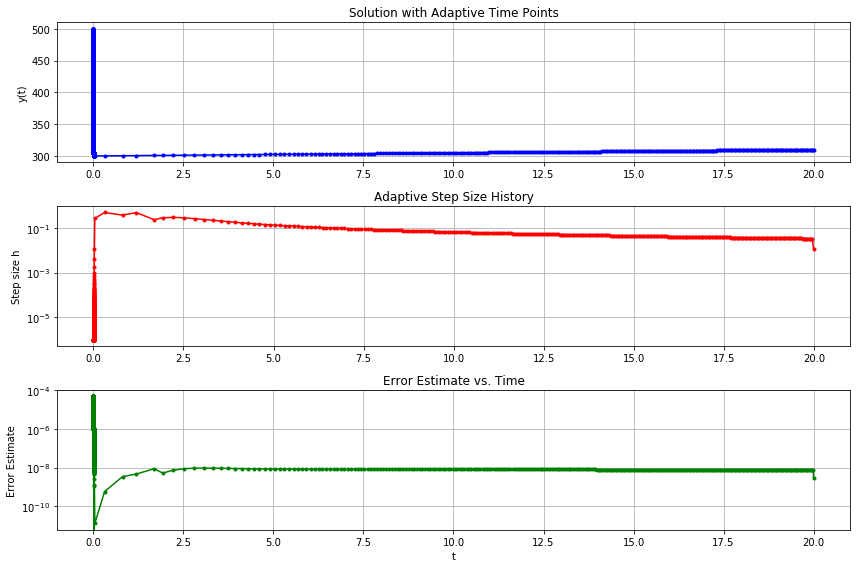

In [140]:
# For small tolerance

t_adapt, y_adapt, h_hist, e_hist, stats = adaptive_implicit_euler(
    f, y0, t0, t_final, h0=0.1, tol=1e-8
)

print("\nPerformance Comparison:")
print(f"{'Method':<20} {'Steps':<10} {'Func Evals':<15}")
print("-" * 60)
print(f"{'Fixed (h=0.01)':<20} {len(t_fixed):<10} {len(t_fixed)*3:<15}")
print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {stats['function_evals']:<15}")


# Visualize how step size adapts
plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, 'b-o', markersize=3)
plt.ylabel('y(t)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
plt.ylabel('Step size h')
plt.title('Adaptive Step Size History')
plt.grid(True)

plt.subplot(3, 1, 3)
# Plot error estimate
plt.semilogy(t_adapt[1:], e_hist, 'g-o', markersize=3)
plt.ylabel('Error Estimate')
plt.xlabel('t')
plt.title('Error Estimate vs. Time')
plt.grid(True)

plt.tight_layout()
plt.show()


In [142]:
"""
As seen in the above graphs, trhe adaptive solver handles
both cases (large initial h0 and tight tolerance) gracefully.
"""

pass

# Section 6: Conclusions

In [143]:
"""
Damping is needed when a system becomes unstable or starts oscillating, 
causing updates to overshoot or diverge. It works by reducing step sizes 
or adjusting dampening constant so the system settles smoothly instead 
of reacting too aggressively.

Adaptive step sizes are worth using when the system changes in difficulty
across the domain, such as being smooth in some areas and rapidly changing
in others. They improve efficiency and accuracy by automatically using large
steps where possible and small steps where necessary.

In conclusion, damping is used to stabilize unstable or oscillatory behavior, 
while adaptive step sizes improve efficiency and accuracy by automatically 
adjusting step size to match how difficult the problem is at each point.
"""

pass